# 🧬 Model Development – Immunotherapy Response Prediction
## Hackathon DIGPHAT-CANVAS – PharmacogenomicDay

**Use Case:** Multi-modal prediction of Immunotherapy response for ccRCC patients with follow-up post-Immune Checkpoint Blockade (ICB).

In this notebook we will:
1. Explore & integrate five omics/clinical modalities
2. Define the clinical outcome (RECIST response)
3. Preprocess each data modality (leakage-controlled)
4. Engineer features & reduce dimensionality
5. Train and evaluate multiple ML classifiers
6. Save the best model & preprocessing artifacts for the **Deployment Notebook**

In [1]:
import pandas as pd
import numpy as np
import os, warnings, joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score,cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
# from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import miceforest as mf
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42

def plot_pca_2d(X_data, y_labels, title="2D PCA Projection", random_state=42):
    """
    Fits a 2D PCA on the provided features and plots the result colored by labels.
    
    Parameters:
    - X_data: DataFrame or array of features.
    - y_labels: Series or array of target labels (0 or 1).
    - title: String title for the plot.
    - random_state: Seed for reproducibility.
    """
    # Fit PCA with 2 components
    pca_2d = PCA(n_components=2, random_state=random_state)
    X_pca_2d = pca_2d.fit_transform(X_data)
    
    # Store results in a DataFrame for seaborn
    pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
    
    # Reset index to avoid misalignment if y_labels has an index
    if hasattr(y_labels, 'reset_index'):
        pca_df['Response'] = y_labels.reset_index(drop=True)
    else:
        pca_df['Response'] = y_labels

    # Create the scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='PC1', y='PC2', 
        hue='Response', 
        data=pca_df, 
        palette={0: 'darkorange', 1: 'steelblue'}, 
        alpha=0.7, 
        s=60
    )
    
    # Annotate with explained variance
    var_ratio = pca_2d.explained_variance_ratio_ * 100
    plt.xlabel(f'Principal Component 1 ({var_ratio[0]:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({var_ratio[1]:.1f}%)')
    plt.title(title)
    
    # Customize legend & styling
    plt.legend(title='Response (1=Responder)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print("All imports OK ✅")

All imports OK ✅


---
# 1. Objective & Clinical Question

**Clinical question:** Can we predict RECIST response (CR/PR vs SD/PD) to immunotherapy from multi-modal patient data?

| Item | Detail |
|------|--------|
| Tumor type | Clear-cell Renal Cell Carcinoma (ccRCC) |
| Treatment | Immune Checkpoint Blockade (Nivolumab) |
| Outcome | Binary RECIST: **Responder** (CR/PR) vs **Non-Responder** (SD/PD) |
| Sites | Primary + metastatic samples |

---
# 2. Dataset Overview

## 2.1 Modalities

| # | Modality | Description |
|---|----------|-------------|
| 1 | **Clinical** | Demographics, treatment, tumour characteristics, RECIST |
| 2 | **Genomic** | Somatic mutations & copy-number alterations |
| 3 | **Immune deconvolution** | [CIBERSORTx](https://cibersortx.stanford.edu/) cell-type proportions from bulk RNA-seq |
| 4 | **Pathway scores** | ssGSEA scores for 50 [Hallmark pathways](https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=H) |
| 5 | **Transcriptomic** | Gene-level TPM expression (~40 k genes) |

---
The cohort is collected from the study by Braun et al. (2020) [Nature Medicine](https://www.nature.com/articles/s41591-020-0839-y) consisting of ccRCC patients treated with Nivolumab. We split the data into a training set (80%) and a hold-out test set (20%) for final evaluation.

- The **training set** → used in this notebook for model development (with cross-validation).
- The **test set** → held out for the **Deployment Notebook** (blind evaluation).

In [2]:
#Load training data of all five modalities

clinical_train_df = pd.read_csv('Data/train/clinical.csv')
genomic_train_df = pd.read_csv('Data/train/genomic.csv')
deconv_train_df = pd.read_csv('Data/train/cell_deconvolution.csv')
ssgsea_train_df = pd.read_csv('Data/train/ssgsea.csv')
transcriptomic_train_df = pd.read_csv('Data/train/transcriptomic.csv')

# ── Quick look at each modality ───────────────────────────────────────────────
for name, df in [('Clinical', clinical_train_df), ('Genomic', genomic_train_df),
                 ('Deconvolution', deconv_train_df), ('ssGSEA', ssgsea_train_df),
                 ('Transcriptomic', transcriptomic_train_df)]:
    print(f"\n{'='*60}")
    print(f"  {name}: Shape = {df.shape}")
    print(f"{'='*60}")
    display(df.head(3))


  Clinical: Shape = (224, 11)


,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,SD
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,PR
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,INTERMEDIATE,No,No,2.0,PRIMARY,SD



  Genomic: Shape = (224, 34)


,Patient_ID,Amplification_5q31.3,Amplification_5q35.3,Deletion_3p21.1,Deletion_6p22.2,Deletion_6p21.32,Deletion_6p12.1,Deletion_9p21.3,Deletion_9q34.3,Deletion_10q23.31,...,SETD2,SMARCA4,TCEB1,TP53,TRMT2B,TSC1,USP32,VHL,WNT8A,ZNF800
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,MUT,MUT,MUT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,MUT,WT,WT
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,WT,WT,MUT,WT,WT,WT,MUT,MUT,MUT,...,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT



  Deconvolution: Shape = (224, 27)


,Patient_ID,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Absolute score (sig.score)
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.046327,0.086641,0.015842,0.185357,0.0,0.204351,0.022605,0.050186,0.009508,...,0.042027,0.021309,0.057458,0.0,0.009780,0.053686,0,0.923779,0.650795,1.274922
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.069083,0.050311,0.035438,0.101136,0.0,0.179168,0.035013,0.087914,0.000000,...,0.023344,0.019054,0.094429,0.0,0.000000,0.075189,0,0.917443,0.667743,1.304494
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0.014722,0.085358,0.009111,0.049616,0.0,0.208555,0.057945,0.098924,0.000000,...,0.016985,0.005598,0.084503,0.0,0.019692,0.055920,0,0.888383,0.686416,1.163864



  ssGSEA: Shape = (224, 51)


,Patient_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.645208,0.613143,0.640741,0.544471,0.477824,0.356894,0.653818,0.393865,0.589824,...,0.792464,0.729333,0.128080,0.670299,0.571636,0.717934,0.662968,0.512491,0.432010,0.477736
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.745334,0.481716,0.692472,0.656193,0.583043,0.523270,0.671667,0.518503,0.672382,...,0.821810,0.773135,0.139733,0.745215,0.604999,0.734874,0.713620,0.574449,0.514951,0.629333
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0.756409,0.462137,0.704921,0.596222,0.552728,0.398848,0.646143,0.456058,0.698500,...,0.822478,0.756662,0.131104,0.769317,0.582469,0.764036,0.716527,0.572508,0.487859,0.532403



  Transcriptomic: Shape = (224, 40935)


,Patient_ID,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,22.45228,34.75424,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,32.02459,32.43928,28.87370,29.40491,34.00210,21.13002,31.87140,31.90028,21.26386,28.67162
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,26.08813,33.57834,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,33.92360,33.17470,32.86634,32.95676,34.37301,21.13002,33.46758,32.99777,21.26386,33.29667
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,22.45228,34.02825,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,27.94141,29.16648,28.87370,29.40491,32.73904,21.13002,30.58496,28.49402,21.26386,28.67162


## 2.2. Data Description

In [3]:
# ── Training data summary ────────────────────────────────────────────────────────────
print(f"Total patients: {len(clinical_train_df)}")
print(f"\nORR distribution:")
print(clinical_train_df['ORR'].value_counts().to_string())
print(f"\nCohorts: {clinical_train_df['Cohort'].unique()}")
print(f"Treatment arms: {clinical_train_df['Arm'].unique()}")

Total patients: 224

ORR distribution:
ORR
SD      100
PD       89
CRPR     24
PR       10
CR        1

Cohorts: <ArrowStringArray>
['CM-010', 'CM-025', 'CM-009']
Length: 3, dtype: str
Treatment arms: <ArrowStringArray>
['NIVOLUMAB', 'EVEROLIMUS']
Length: 2, dtype: str


### 2.2.1. Outcome Definition
We define a **binary** outcome for immunotherapy response:
- **1 (Responder):** CR (Complete Response), PR (Partial Response), CRPR
- **0 (Non-Responder):** SD (Stable Disease), PD (Progressive Disease)

,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR,Response
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,SD,0
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,PR,1
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,INTERMEDIATE,No,No,2.0,PRIMARY,SD,0


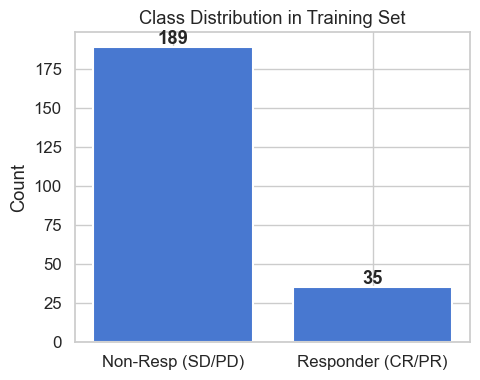

Responders: 35  |  Non-Responders: 189  |  Ratio: 1:5.4


In [4]:
# Map ORR to binary label
response_map = {'CR': 1, 'PR': 1, 'CRPR': 1, 'SD': 0, 'PD': 0}
clinical_train_df['Response'] = clinical_train_df['ORR'].map(response_map)
display(clinical_train_df.head(3))

resp_counts = clinical_train_df['Response'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Non-Resp (SD/PD)', 'Responder (CR/PR)'], resp_counts.values, edgecolor='white', linewidth=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_ylabel('Count'); ax.set_title('Class Distribution in Training Set')
plt.tight_layout(); plt.show()

ratio = resp_counts[1] / resp_counts[0]
print(f"Responders: {resp_counts[1]}  |  Non-Responders: {resp_counts[0]}  |  Ratio: 1:{1/ratio:.1f}")

### 2.2.2 Missing Data

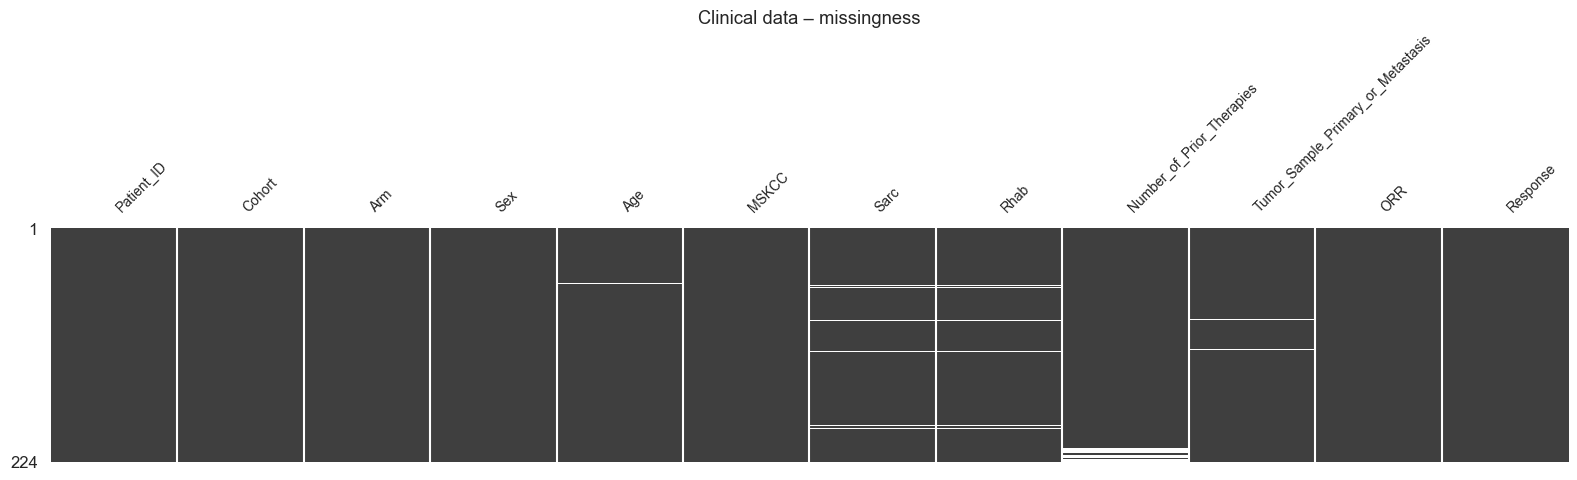

Total missing values in transcriptomic data: 0


In [5]:
fig, axes = plt.subplots(1,1, figsize=(16, 5))
msno.matrix(clinical_train_df, ax=axes, sparkline=False, fontsize=10)
axes.set_title('Clinical data – missingness')
# msno.matrix(genomic_train_df.iloc[:, :34], ax=axes[1], sparkline=False, fontsize=10)
# axes[1].set_title('Genomic data – missingness')
plt.tight_layout()
plt.show()

print(f"Total missing values in transcriptomic data: {transcriptomic_train_df.isna().sum().sum()}")

# 3. Data Preprocessing & Feature Engineering

> **Leakage-controlled:** Every transformation (scaling, imputation, PCA, feature
> selection) is **fit on the training set only** and later applied to the test set
> in the Deployment Notebook.

## 3.1 Transcriptomic Data (RNA-seq)

The expression matrix contains **~40 000 genes** measured in **TPM** (Transcripts Per Million).

**Pre-processing steps:**
- The data is **already normalised to TPM**.
- We **filter low-expression genes** by removing genes below a variance threshold.
- We **standardise** the remaining genes.
- Sometimes, Gene identifiers are Ensembl IDs (e.g. `ENSG00000141510.18`).
  In a production pipeline you would convert them to HUGO symbols (`mygene` library, etc.). Here we keep Ensembl IDs for simplicity.

In [6]:
# ── 4.1  Transcriptomic processing ────────────────────────────────────────────
train_trans = transcriptomic_train_df.drop('Patient_ID', axis=1).copy()

# Filter low-expression genes  (under variance threshold)
gene_var = train_trans.var()
var_cutoff = 0.05 #we can also use quantile-based cutoff (e.g. top 50% variance)
keep_genes = gene_var[gene_var > var_cutoff].index.tolist()
train_trans = train_trans[keep_genes]
print(f"Genes kept after variance filter: {len(keep_genes)} / {len(gene_var)}")


# Standardise
trans_scaler = StandardScaler()
train_trans_scaled = pd.DataFrame(
    trans_scaler.fit_transform(train_trans),
    columns=keep_genes
)
print(f"Transcriptomic feature matrix: {train_trans_scaled.shape}")

Genes kept after variance filter: 38030 / 40934
Transcriptomic feature matrix: (224, 38030)


## 3.2 Somatic Mutation Data

The genomic dataset contains somatic **mutation status** and **copy-number alterations**.

Values: `MUT` (mutated) / `WT` (wild-type) / **`NO_IF`** (no information).

We can treat these as categorical features, but we need to handle the `NO_IF` values carefully. We can consider it as missing values or as a separate category depending on the context. At the first step, we won't use this information in our model, but you can try to play with it.

## 3.3 ssGSEA Pathway Scores (Hallmark)

50 Hallmark pathway enrichment scores computed with [GSEAPy](https://gseapy.readthedocs.io/).
```python
import gseapy as gp
# txt, gct file input
ss = gp.ssgsea(data='./tests/extdata/Leukemia_hgu95av2.trim.txt',
               gene_sets='./tests/extdata/h.all.v7.0.symbols.gmt',
               outdir=None,
               sample_norm_method='rank', # choose 'custom' will only use the raw value of `data`
               no_plot=True)
```
We **standardise** them (zero mean, unit variance) before model training.

In [7]:
# ── 4.4  Pathway scaling ───────────────────────────────────────────────────────
train_pathway = ssgsea_train_df.drop('Patient_ID', axis=1).copy()

pathway_scaler = StandardScaler()
train_pathway_scaled = pd.DataFrame(
    pathway_scaler.fit_transform(train_pathway),
    columns=train_pathway.columns
)
print(f"Pathway features: {train_pathway_scaled.shape[1]}")

Pathway features: 50


## 3.4 Immune Cell Deconvolution (CIBERSORTx)

Cell-type proportions estimated from bulk RNA-seq. We leverage the [CIBERSORTx](https://cibersortx.stanford.edu/) tool to deconvolve bulk transcriptomic data into immune cell-type proportions. The output consists of relative abundances of various immune cell types (e.g., CD8+ T cells, macrophages, etc.) for each sample. 

We used LM22 signature matrix for deconvolution, which includes 22 immune cell types. The resulting cell-type proportions are compositional data (i.e., they sum to 1 for each sample).

Since these are **compositional data** (proportions summing to ~1), we apply a **centered-logratio (CLR) transform**.

In [8]:
cell_cols = [
    c for c in deconv_train_df.columns
    if c not in ["Patient_ID", "P-value", "Correlation", "RMSE", "Absolute score (sig.score)"]
]

X = deconv_train_df[cell_cols].copy()

# Small epsilon to avoid log(0)
eps = 1e-6
X_eps = X + eps

# Geometric mean per sample (row)
geo_mean = np.exp(np.log(X_eps).mean(axis=1))

# CLR: log(x / g(x)) for each row
clr_values = np.log(X_eps.div(geo_mean, axis=0))
deconv_clr_df = pd.DataFrame(clr_values, columns=cell_cols)

#Scaled CLR values
clr_scaler = StandardScaler()
deconv_clr_scaled = clr_scaler.fit_transform(deconv_clr_df)
deconv_clr_df = pd.DataFrame(deconv_clr_scaled, columns=cell_cols)


display(deconv_clr_df.head(3))

,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Monocytes,Macrophages M0,Macrophages M1,Macrophages M2,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils
0,-0.180077,-0.156633,-0.027753,-0.249186,-0.573604,-0.726541,-0.018866,-2.105710,1.259640,0.872660,...,-1.934257,0.763863,-0.742317,-1.256990,0.107029,-0.81205,0.126820,-1.969689,0.321535,0.037507
1,0.627546,0.214808,0.741639,0.269699,0.078430,0.697218,0.514127,0.617571,-0.678991,0.795649,...,1.264156,-1.340876,1.129417,0.670025,0.415557,-0.02384,0.703849,-1.682839,-1.822439,0.855310
2,0.157457,0.860008,0.456281,0.184232,0.411702,1.716522,0.877653,1.749014,-0.529414,-0.909790,...,1.190554,-1.200217,1.821545,1.677629,0.564447,-0.46562,0.874766,-1.536221,0.996713,1.024371


## 3.5 Clinical Data

- **Categorical variables** (Arm) → one-hot encoding

- **Ordinal variables** (MSKCC, Number_of_Prior_Therapies) → ordinal encoding

- **Binary variables** (Sarc, Rhab, Sex, Tumor_Sample_Primary_or_Metastasis) → binary encoding

- **Numerical variables** (Age) → standardisation


Missing values before imputation: 64


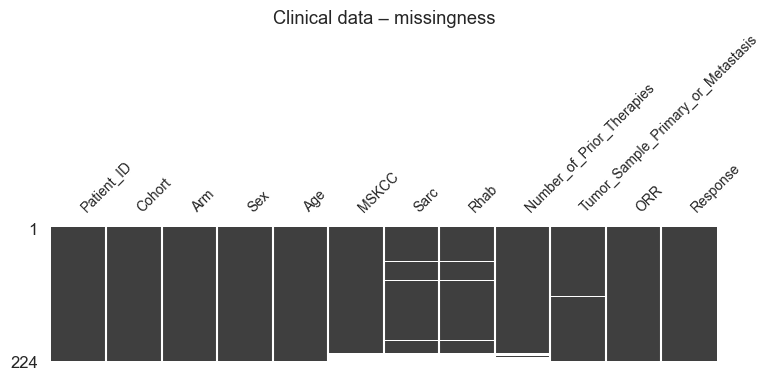

In [9]:
# Replace NO-IF with NaN for Sarc and Rhab and MSKCC
for col in ['Sarc', 'Rhab', 'MSKCC']:
    clinical_train_df[col] = clinical_train_df[col].replace('NO_IF', np.nan)

missing_before = clinical_train_df.isna().sum().sum()
print(f"Missing values before imputation: {missing_before}")
#Visualize missingness in clinical data 
fig, ax = plt.subplots(figsize=(8, 4))
msno.matrix(clinical_train_df, ax=ax, sparkline=False, fontsize=10)
plt.title('Clinical data – missingness')
plt.tight_layout()
plt.show()  

In [10]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Drop Cohort column
train_clinic = clinical_train_df.drop(columns=['Cohort']).copy()
# ── Define column groups ───────────────────────────────────────────────────────
dummy_cols = ['Arm']                           # One-hot encoding
binary_cols = ['Sex', 'Sarc', 'Rhab', 'Tumor_Sample_Primary_or_Metastasis']  # Binary
ordinal_cols = ['MSKCC', 'Number_of_Prior_Therapies']  # Ordinal encoding
num_cols = ['Age']                             # Standardization

# Storage for transformers (to apply later on test/external data)
transformers = {}
# ── 1. One-Hot Encoding for 'Arm' ─────────────────────────────────────────────
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
arm_encoded = ohe.fit_transform(train_clinic[[dummy_cols[0]]])
arm_df = pd.DataFrame(
    arm_encoded, 
    columns=ohe.get_feature_names_out([dummy_cols[0]]),
    index=train_clinic.index
)
transformers['ohe_Arm'] = ohe

In [11]:
# ── 2. Binary Encoding ────────────────────────────────────────────────────────
# Simple 0/1 encoding (assumes values like 'Male/Female', 'Yes/No', etc.)
binary_encoded = train_clinic[binary_cols].copy()
for col in binary_cols:
    le = LabelEncoder()
    binary_encoded[col] = le.fit_transform(binary_encoded[col].astype(str))
    transformers[f'le_{col}'] = le

In [12]:
# ── 3. Ordinal Encoding ───────────────────────────────────────────────────────
# MSKCC: FAVORABLE > INTERMEDIATE > POOR
# Number_of_Prior_Therapies: already numeric, but treat as ordinal
mskcc_order = [['POOR', 'INTERMEDIATE', 'FAVORABLE', np.nan]] 
ordinal_encoded = train_clinic[ordinal_cols].copy()
# MSKCC - ordinal
mskcc_oe = OrdinalEncoder(categories=mskcc_order, handle_unknown='use_encoded_value', unknown_value=-1,encoded_missing_value=np.nan)
ordinal_encoded['MSKCC'] = mskcc_oe.fit_transform(ordinal_encoded[['MSKCC']])
transformers['oe_MSKCC'] = mskcc_oe

In [13]:
# ── 4. Numerical Scaling ─────────────────────────────────────────────────────
age_scaled = train_clinic[num_cols].copy()
scaler = StandardScaler()
age_scaled[num_cols] = scaler.fit_transform(age_scaled[num_cols])
transformers['scaler_Age'] = scaler

In [14]:
# ── Combine all encoded features ──────────────────────────────────────────────
train_clinical_encoded = pd.concat([
    arm_df,
    binary_encoded,
    ordinal_encoded,
    age_scaled
], axis=1)

display(train_clinical_encoded.head(3))
print(f"\nEncoded clinical shape: {train_clinical_encoded.shape}")

,Response,Arm_EVEROLIMUS,Arm_NIVOLUMAB,Sex,Sarc,Rhab,Tumor_Sample_Primary_or_Metastasis,MSKCC,Number_of_Prior_Therapies,Age
0,0,0.0,1.0,1,0,0,1,2.0,2.0,0.041661
1,1,0.0,1.0,0,0,0,1,0.0,1.0,0.041661
2,0,0.0,1.0,1,0,0,1,1.0,2.0,1.455420



Encoded clinical shape: (224, 10)


### 3.5.1. Handling Missing Values in Clinical Data

We impute missing values using **MICE** (Multiple Imputation by Chained Equations) via the `miceforest` library.

In [15]:
kernel = mf.ImputationKernel(train_clinical_encoded, random_state=RANDOM_STATE)
kernel.mice(iterations=10, verbose=False)
train_clinical_imputed = kernel.complete_data()
# Re-attach Response (was excluded from MICE to prevent target leakage)
train_clinical_imputed = pd.concat([
    train_clinic[['Response']].reset_index(drop=True),
    train_clinical_imputed.reset_index(drop=True)
], axis=1)

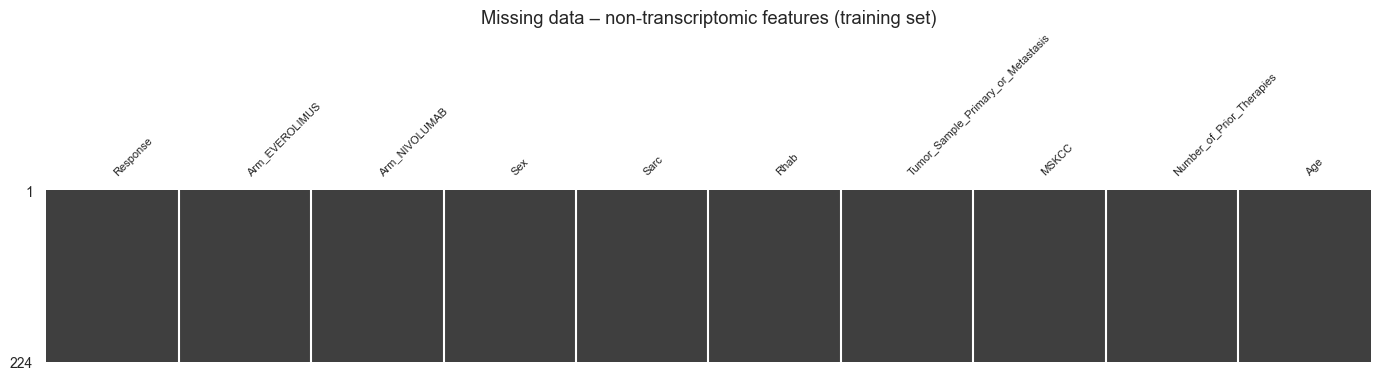

In [16]:
msno.matrix(train_clinical_imputed, figsize=(14, 4), sparkline=False, fontsize=8)
plt.title('Missing data – non-transcriptomic features (training set)')
plt.tight_layout()
plt.show()

train_clinical_processed = pd.concat([
    train_clinic[['Patient_ID']],
    train_clinical_imputed], axis=1)

## **3.6. Integrate all preprocessed features**

In [17]:
df_train_all = pd.concat([
    train_clinical_processed,
    train_trans_scaled,
    train_pathway_scaled,
    deconv_clr_df], axis=1)
display(df_train_all.head())

,Patient_ID,Response,Arm_EVEROLIMUS,Arm_NIVOLUMAB,Sex,Sarc,Rhab,Tumor_Sample_Primary_or_Metastasis,MSKCC,Number_of_Prior_Therapies,...,Monocytes,Macrophages M0,Macrophages M1,Macrophages M2,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0,0.0,1.0,1,0,0,1,2.0,2.0,...,-1.934257,0.763863,-0.742317,-1.256990,0.107029,-0.812050,0.126820,-1.969689,0.321535,0.037507
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,1,0.0,1.0,0,0,0,1,0.0,1.0,...,1.264156,-1.340876,1.129417,0.670025,0.415557,-0.023840,0.703849,-1.682839,-1.822439,0.855310
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0,0.0,1.0,1,0,0,1,1.0,2.0,...,1.190554,-1.200217,1.821545,1.677629,0.564447,-0.465620,0.874766,-1.536221,0.996713,1.024371
3,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,0,0.0,1.0,0,0,0,1,2.0,3.0,...,0.758421,0.383159,1.046238,0.528261,0.213166,-0.254659,0.357321,-1.733791,0.082008,0.685181
4,G138701_RCCBMS-00116-T_v1_RNA_OnPrem,0,0.0,1.0,1,0,0,1,0.0,2.0,...,-0.851817,0.679393,-1.440730,-1.208248,0.096057,-0.149482,0.147502,0.342260,0.476714,-0.139792


# **4. Baseline model**

## **4.1. Cross Validation**

In [18]:
X_train_all = df_train_all.drop(columns=['Patient_ID', 'Response'])
y_train = df_train_all['Response']

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
scoring = {
    'roc_auc':   'roc_auc',
    'pr_auc':   'average_precision',
    'bal_acc':   'balanced_accuracy',
    'f1':        'f1',
    'mcc':       'matthews_corrcoef',
}

logit = LogisticRegression(penalty='l2', max_iter=2000, random_state=RANDOM_STATE)
for score in scoring.values():
    # Note we use X_train_final here instead of X_train_sel so feature selection happens inside CV
    cv_res = cross_val_score(logit, X_train_all, y_train, cv=cv, scoring=score, n_jobs=-1)
    print(f"{score:25s}  {cv_res.mean():.3f}±{cv_res.std():.3f}")

roc_auc                    0.386±0.095


average_precision          0.164±0.037


balanced_accuracy          0.492±0.025


f1                         0.013±0.050


matthews_corrcoef          -0.024±0.065


## **4.2. Learning Curves**
A learning curve helps diagnose **overfitting** (large train–test gap) and
**underfitting** (both curves plateau at low score).

NameError: name 'pipeline' is not defined

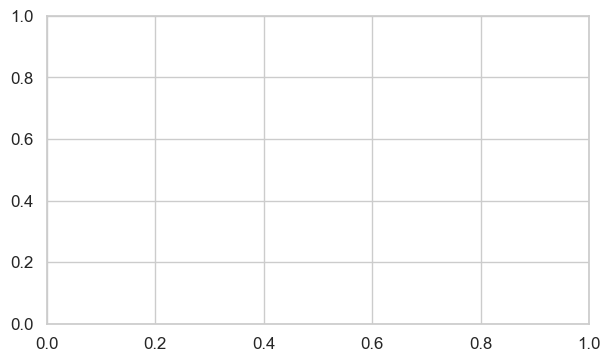

In [19]:
# ── 6.3  Learning curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X_train_all, y_train, cv=cv, scoring='balanced_accuracy',
    n_jobs=-1, random_state=RANDOM_STATE)

ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
ax.set_xlabel('Training set size'); ax.set_ylabel('Balanced Accuracy')
ax.legend()
plt.title('Learning Curve (L1 Selector + L2 Logistic Regression)')
plt.show()


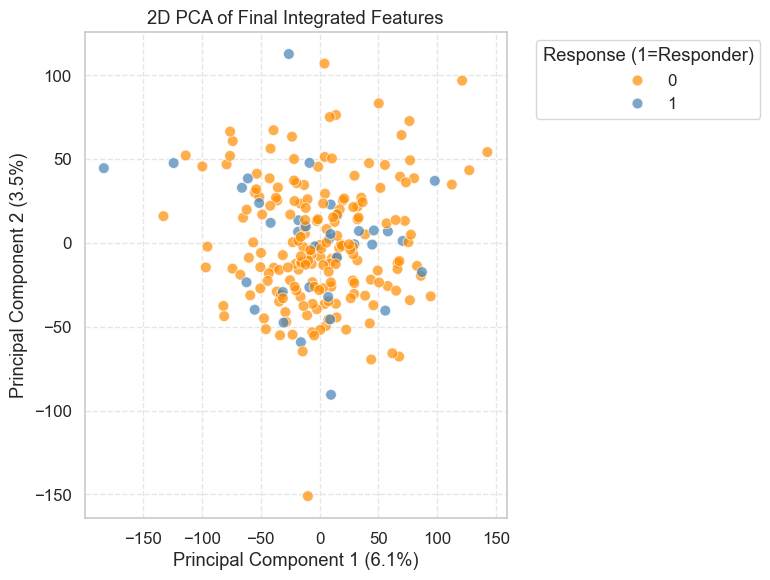

In [20]:
plot_pca_2d(X_train_all, y_train, title="2D PCA of Final Integrated Features")

# **5. Model Developement**

## **5.1. Feature Selection & Dimensionality Reduction**

## **5.1.1. Embedded Methods**
We use **Logistic Regression** to perform embedded feature selection. The `SelectFromModel` class from `sklearn` allows us to select features based on the importance weights learned by the logistic regression model.

```python
model = LogisticRegression(random_state=RANDOM_STATE)
selector = SelectFromModel(model, prefit = False)

X_train_sel = selector.fit_transform(X_train_final, y_train)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")
```

## **5.1.2. Wrapper Methods**
We can also use **Recursive Feature Elimination (RFE)** with a logistic regression estimator to iteratively select features by recursively considering smaller and smaller sets of features.

```python
from sklearn.feature_selection import RFE
estimator = LogisticRegression(random_state=RANDOM_STATE)
selector = RFE(estimator, n_features_to_select=20, step=1)
selector = selector.fit(X_train_final, y_train)
X_train_sel = selector.transform(X_train_final)
```

## **5.2. Dimensionality Reduction with PCA**
We can apply **Principal Component Analysis (PCA)** to reduce the dimensionality of the transcriptomic features while retaining most of the variance. We can select the number of principal components based on the cumulative explained variance (e.g., retaining 95% of the variance).
```python
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_result = pca.fit_transform(X_train_transcriptomic_scaled) 
```

In [21]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_result = pca.fit_transform(train_trans_scaled)
n_pcs = train_pca_result.shape[1]
pca_columns = [f'PC{i+1}' for i in range(n_pcs)]
train_pca_df = pd.DataFrame(
    train_pca_result, 
    columns=pca_columns,
    index=train_trans_scaled.index)

df_train_all_pca = pd.concat([
    train_clinical_processed,  #Clinical
    train_pathway_scaled,      # Pathways
    deconv_clr_df,             # Deconvolution (miễn dịch)
    train_pca_df               # Transcriptomic đã được giảm chiều qua PCA
], axis=1)

X_train_pca = df_train_all_pca.drop(columns = ['Patient_ID', 'Response'])
display(X_train_pca.head(3))

,Arm_EVEROLIMUS,Arm_NIVOLUMAB,Sex,Sarc,Rhab,Tumor_Sample_Primary_or_Metastasis,MSKCC,Number_of_Prior_Therapies,Age,HALLMARK_ADIPOGENESIS,...,PC187,PC188,PC189,PC190,PC191,PC192,PC193,PC194,PC195,PC196
0,0.0,1.0,1,0,0,1,2.0,2.0,0.041661,-1.804004,...,-1.124826,-8.640794,4.733344,5.047419,0.025520,-0.611952,-3.517561,5.875398,9.586873,0.135166
1,0.0,1.0,0,0,0,1,0.0,1.0,0.041661,1.984468,...,-8.385587,10.326487,8.171846,10.391849,3.540521,4.623102,4.718815,22.373317,2.467775,-4.064931
2,0.0,1.0,1,0,0,1,1.0,2.0,1.455420,2.403511,...,-1.079827,-0.140557,0.605520,-0.092348,-2.216540,2.298117,-0.938349,-0.257469,-0.419414,1.188554


## **4.4. Data Sampling**


- **Oversampling**

    - **Oversampling** aims to balance the dataset by increasing the number of samples in the minority class. The simplest form is **Random Oversampling**, which duplicates existing minority instances. While this balances the class distribution, it carries a high risk of **overfitting**, as the model essentially "memorizes" specific data points rather than learning general patterns.

- **Undersampling**

    - **Undersampling** balances the dataset by removing instances from the majority class. This is often used when you have a massive dataset and want to reduce computational costs. However, the major drawback is **information loss**—you might discard critical data points that define the majority class's boundary, potentially leading to a model that underperforms on real-world data.

- **SMOTE** is a more sophisticated "informed" oversampling technique. Instead of duplicating rows, it selects a minority class point and identifies its $k$-nearest neighbors. It then creates **synthetic** data points along the line segments connecting these neighbors. This "stretches" the minority class region, helping the model learn a more robust decision boundary and reducing the likelihood of overfitting.

- **ADASYN** builds upon the SMOTE concept but adds an **adaptive** mechanism. It focuses on the "hard-to-learn" parts of the feature space. ADASYN looks for minority samples that are surrounded by many majority class points (the "borderline" or "noisy" areas) and generates more synthetic data there. This forces the model to pay more attention to the most difficult areas where the classes overlap, rather than wasting resources on "easy" areas.

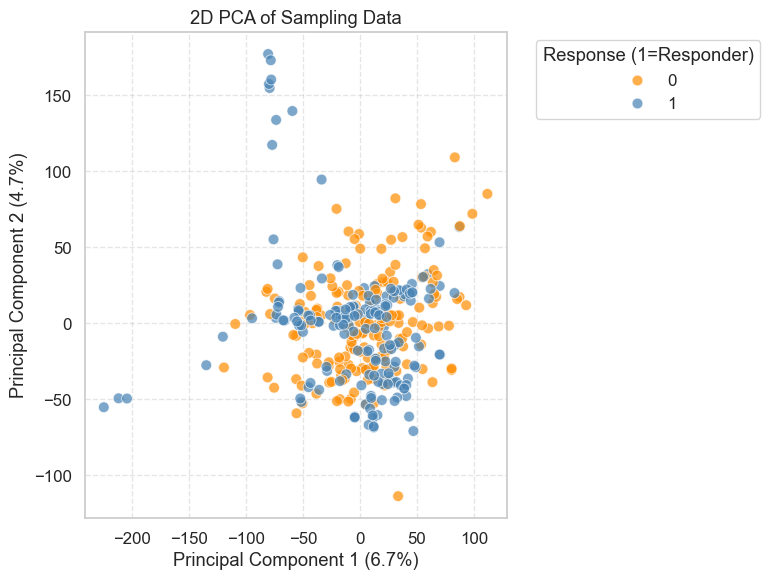

In [22]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_train_all, y_train)
plot_pca_2d(X_res, y_res, title="2D PCA of Sampling Data")

# **5. Model Optimization**

We will apply these strategies to optimize model performance. To avoid Data Leakage, all preprocessing steps—including feature selection, data sampling, and dimensionality reduction—must be executed strictly within the cross-validation loop.

To achieve this, the `imblearn` library provides a `Pipeline` module. This allows us to integrate multiple transformations into a single estimator, ensuring that the sampling and reduction techniques are only fitted on the training folds and never "see" the validation data.

In [23]:
import warnings, os, joblib
from imblearn.pipeline import Pipeline 
warnings.filterwarnings('ignore', category=FutureWarning)   # hide the deprecation warnings
warnings.filterwarnings('ignore', category=UserWarning)    # hide any harmless user‑warnings

logit = LogisticRegression(penalty='l2', max_iter=2000, random_state=RANDOM_STATE)

pipeline = Pipeline(
    [('sampler', ADASYN(random_state=RANDOM_STATE)),
    ('feature selector', SelectKBest(score_func=mutual_info_classif)),
    ('classifier', logit)]
) 

scoring = {
    'roc_auc':   'roc_auc',
    'pr_auc':   'average_precision',
    'bal_acc':   'balanced_accuracy',
    'f1':        'f1',
    'mcc':       'matthews_corrcoef',
}


cv_results = cross_validate(
                estimator   = pipeline,
                X           = X_train_pca,
                y           = y_train,
                cv          = cv,
                scoring     = scoring,
                n_jobs      = -1,      
             )
print("\n=== Cross‑validation performance (mean ± std) ===")
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    print(f"{metric:25s}  {np.mean(scores):.3f} ± {np.std(scores):.3f}")


NameError: name 'ADASYN' is not defined

In [24]:
# Feature importance from the pipeline's logistic regression coefficients
pipeline.fit(X_train_pca, y_train)

# Extract the fitted steps
fitted_selector = pipeline.named_steps['feature selector']
fitted_logit = pipeline.named_steps['classifier']

feature_importance = np.abs(fitted_logit.coef_[0])
feature_names = X_train_pca.columns[fitted_selector.get_support()]

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=True)
display(feat_imp_df.head(10))


NameError: name 'pipeline' is not defined

---
# **6. Save Model & Preprocessing Artifacts**

All fitted objects are saved so the **Deployment Notebook** can apply the
exact same pipeline to the held-out test set.

In [25]:
os.makedirs('artifacts', exist_ok=True)

# Artifact dictionary to save all fitted objects and metadata for deployment

artifacts = {
    # ── Fitted Pipeline (ADASYN + SelectKBest + LogisticRegression) ────────
    'pipeline':          pipeline,           # the FITTED imblearn Pipeline
    'model_name':        'ADASYN + SelectKBest + LogisticRegression',

    # ── PCA (fitted on training transcriptomics) ──────────────────────────
    'pca':               pca,                # fitted PCA object
    'pca_columns':       pca_columns,        # ['PC1', 'PC2', ...]

    # ── Transcriptomic ────────────────────────────────────────────────────
    'keep_genes':        keep_genes,          # variance-filtered gene list
    'trans_scaler':      trans_scaler,        # StandardScaler fitted on train

    # ── ssGSEA Pathways ───────────────────────────────────────────────────
    'pathway_scaler':    pathway_scaler,      # StandardScaler fitted on train

    # ── Cell Deconvolution ────────────────────────────────────────────────
    'cell_cols':         cell_cols,            # column names for deconv features
    'clr_scaler':        clr_scaler,          # StandardScaler on CLR values

    # ── Clinical Encoders ─────────────────────────────────────────────────
    'encoders':          transformers,         # ohe_Arm, le_*, oe_MSKCC, scaler_Age
    'dummy_cols':        dummy_cols,           # ['Arm']
    'binary_cols':       binary_cols,
    'ordinal_cols':      ordinal_cols,
    'num_cols':          num_cols,             # ['Age']

    # ── Imputation ────────────────────────────────────────────────────────
    'mice_kernel':       kernel,               # fitted MICE kernel

    # ── Feature column order (for alignment in deployment) ────────────────
    'feature_columns':   list(X_train_pca.columns),
}

joblib.dump(artifacts, 'artifacts/pipeline_artifacts.joblib')
print('Artifacts saved to artifacts/pipeline_artifacts.joblib')
print(f'   Pipeline: {artifacts["model_name"]}')
print(f'   PCA components: {len(pca_columns)}')
print(f'   Feature columns: {len(artifacts["feature_columns"])}')
print(f'   Keys: {list(artifacts.keys())}')


NameError: name 'pipeline' is not defined

---
# **7. Ideas for Model Improvement**

Here are strategies you can explore to push performance further:

| Strategy | Description |
|----------|-------------|
| **SMOTE**, **ADASYN** | Synthetic Minority Oversampling to handle class imbalance (`imblearn.over_sampling.SMOTE`) |
| **Hyperparameter tuning** | `GridSearchCV` or `Optuna` for systematic search |
| **Feature selections** | Try different feature selection techniques (e.g., RFE, SelectKBest, [ROOFs](https://gitlab.inria.fr/compo/roofs)) |
|**Other machine learning models**||
| **Ensemble methods** | Stacking, blending multiple base models |


> 💡 **Exercise for students:** Pick one strategy above, implement it,
> and compare CV metrics before vs. after.

## 6. Improved Model DevelopmentWe will now build an **improved pipeline** with:- Integration of **genomic data** alongside transcriptomic features- Multiple classifier types **(XGBoost, LightGBM, Logistic Regression)** for ensemble comparison- **SHAP TreeExplainer** visualizations to understand feature contributions- **Excluding treatment arm** to avoid learning treatment effects rather than biology- Goal: Achieve **ROC-AUC >= 0.60** and robust cross-validation performanceThe following cells will verify dependencies and set up the enhanced modeling pipeline.

In [26]:
# Verify SHAP and XGBoost installation & versions
import shap
import xgboost

print('OK')
print(f'SHAP: {shap.__version__}')
print(f'XGBoost: {xgboost.__version__}')

OK
SHAP: 0.51.0
XGBoost: 3.2.0


### 6.1 Genomic Data IntegrationThe original model development (above) did NOT use the genomic mutation data. Research shows that somatic mutations in **BAP1, PBRM1, VHL, SETD2** are known biomarkers for ccRCC immunotherapy response (Braun et al. 2020).We load `genomic.csv` (224 samples × 34 mutation/CNV features) and encode:- **MUT** → 1 (mutation present)- **WT** → 0 (wild-type)- **NO_IF** → NaN (no information) → fill with 0 (default to WT)We also add a **`has_genomic_data`** binary indicator to flag patients where ALL genomic features are missing (37% of cohort).

In [27]:
# Load genomic matrixgenomic_df = pd.read_csv('Data/train/genomic.csv', index_col='Patient_ID')# Encode MUT→1, WT→0, NO_IF→NaNgenomic_encoded = genomic_df.replace({'MUT': 1, 'WT': 0, 'NO_IF': np.nan}).astype(float)# Add has_genomic_data indicator BEFORE filling NaNhas_genomic = (~genomic_encoded.isna().all(axis=1)).astype(int)genomic_encoded['has_genomic_data'] = has_genomic# Fill remaining NaN with 0 (WT default assumption)genomic_filled = genomic_encoded.fillna(0)print(f'Genomic shape: {genomic_filled.shape}')print(f'Patients with genomic data: {has_genomic.sum()}/{len(has_genomic)} ({100*has_genomic.sum()/len(has_genomic):.1f}%)')print(f'Known biomarkers present: {[col for col in ["BAP1", "PBRM1", "VHL", "SETD2"] if col in genomic_filled.columns]}')

Genomic shape: (137, 34)
Patients with genomic data: 91/137 (66.4%)
Known biomarkers present: ['BAP1', 'PBRM1', 'VHL', 'SETD2']


### 6.2 Combined Feature Matrix (Without PCA)For interpretability in SHAP plots, we build a combined feature matrix that EXCLUDES the PCA-transformed transcriptomics (which produces uninterpretable "PC42" labels).Instead, we combine:- **Clinical** (7 features — excluding Response target AND Arm treatment assignment)- **Pathway scores** (50 ssGSEA Hallmark features)- **Immune deconvolution** (22 CLR-transformed cell types)- **Genomic** (34 mutations + 1 `has_genomic_data` indicator)Total: ~113 interpretable features**Why exclude Arm?** Treatment assignment (Nivolumab vs Everolimus) is NOT a biological characteristic of the patient. Including it would teach the model "This drug works better" (treatment effect) rather than "This biology predicts response" (biological signal). Arm should be excluded to ensure the model generalizes to new treatments.We will use **SelectKBest** in the next step to reduce to <=25 features (N/5 rule for 137 samples).

In [28]:
# Get clinical features WITHOUT the target 'Response' columnclinical_features = train_clinical_imputed.drop(columns=['Response']).reset_index(drop=True)# Remove Arm columns (treatment assignment, not biological predictor)arm_cols = [c for c in clinical_features.columns if c.startswith('Arm')]clinical_features = clinical_features.drop(columns=arm_cols)print(f'Dropped Arm columns: {arm_cols}')# Concatenate all modalities (NO PCA transcriptomics for interpretability)X_combined = pd.concat([    clinical_features,    train_pathway_scaled.reset_index(drop=True),    deconv_clr_df.reset_index(drop=True),    genomic_filled.reset_index(drop=True)], axis=1)# Check for and handle NaN valuesfrom sklearn.impute import SimpleImputernan_count = X_combined.isna().sum().sum()if nan_count > 0:    print(f'⚠️  Found {nan_count} NaN values in X_combined')    nan_cols = X_combined.columns[X_combined.isna().any()].tolist()    print(f'Columns with NaN: {nan_cols}')        # Impute with 0 (safe for binary, scaled, and CLR-transformed features)    imputer = SimpleImputer(strategy='constant', fill_value=0)    X_combined_clean = pd.DataFrame(        imputer.fit_transform(X_combined),        columns=X_combined.columns,        index=X_combined.index    )    X_combined = X_combined_clean    print('✓ NaN values imputed with 0')else:    print('✓ No NaN values detected in X_combined')# Store feature names for SHAP laterfeature_names = list(X_combined.columns)print(f'Combined matrix shape: {X_combined.shape}')print(f'Feature breakdown: Clinical {clinical_features.shape[1]}, Pathway {train_pathway_scaled.shape[1]}, Deconv {deconv_clr_df.shape[1]}, Genomic {genomic_filled.shape[1]}')print(f'Total features: {len(feature_names)}')print(f'Target "Response" in features: {"Response" in feature_names}')

⚠️  Found 2958 NaN values in X_combined
Columns with NaN: ['Amplification_5q31.3', 'Amplification_5q35.3', 'Deletion_3p21.1', 'Deletion_6p22.2', 'Deletion_6p21.32', 'Deletion_6p12.1', 'Deletion_9p21.3', 'Deletion_9q34.3', 'Deletion_10q23.31', 'Deletion_10q26.3', 'Deletion_14q32.33', 'ARID1A', 'ATM', 'BAP1', 'COL9A3', 'KDM5C', 'MTOR', 'NF2', 'PBRM1', 'PCK1', 'PIK3CA', 'PTEN', 'S100B', 'SETD2', 'SMARCA4', 'TCEB1', 'TP53', 'TRMT2B', 'TSC1', 'USP32', 'VHL', 'WNT8A', 'ZNF800', 'has_genomic_data']
✓ NaN values imputed with 0
Combined matrix shape: (224, 115)
Feature breakdown: Clinical 9, Pathway 50, Deconv 22, Genomic 34
Total features: 115
Target "Response" in features: False


### 6.3 Model Comparison: 3 Classifiers with Nested Feature SelectionWe compare **3 research-validated classifiers** for small-sample immunotherapy prediction:1. **L1 Logistic Regression** (liblinear solver) — sparse feature selection, interpretable coefficients2. **Linear SVC** — margin-based classifier, robust for high-dimensional data3. **XGBoost** — gradient boosting with tree ensembles, handles non-linearity**Pipeline structure** (all 3 classifiers):- **StandardScaler**: Zero-center and unit-variance normalization- **SelectKBest (k=20)**: Mutual information feature selection (deterministic with random_state=42)- **Classifier**: With class imbalance handling**Class imbalance handling**:- L1 LogReg & Linear SVC: `class_weight='balanced'` (inversely proportional to class frequencies)- XGBoost: `scale_pos_weight` computed dynamically from actual class distribution**Evaluation**: 5-fold stratified cross-validation × 3 repeats = 15 iterations. Metrics: ROC-AUC (discrimination), F1-score (precision-recall trade-off), Balanced Accuracy (class-imbalanced performance).**Why k=20 features?**: N/5 rule (137 samples / 5 ≈ 27) → conservative k=20 to avoid overfitting.

In [29]:
import functoolsfrom sklearn.pipeline import Pipelinefrom sklearn.preprocessing import StandardScalerfrom sklearn.feature_selection import SelectKBest, mutual_info_classiffrom sklearn.linear_model import LogisticRegressionfrom sklearn.svm import SVCfrom xgboost import XGBClassifierfrom sklearn.model_selection import cross_validateimport numpy as npimport pandas as pd# Deterministic mutual info scorer (G13 guardrail)mi_scorer = functools.partial(mutual_info_classif, random_state=42)# Build 3 pipelinespipelines = {    'L1 LogReg': Pipeline([        ('scaler', StandardScaler()),        ('selector', SelectKBest(score_func=mi_scorer, k=20)),        ('clf', LogisticRegression(            penalty='l1', solver='liblinear', C=0.1,            class_weight='balanced', random_state=42, max_iter=1000        ))    ]),    'Linear SVC': Pipeline([        ('scaler', StandardScaler()),        ('selector', SelectKBest(score_func=mi_scorer, k=20)),        ('clf', SVC(            kernel='linear', C=0.1, class_weight='balanced',            probability=True, random_state=42, max_iter=10000        ))    ]),    'XGBoost': Pipeline([        ('scaler', StandardScaler()),        ('selector', SelectKBest(score_func=mi_scorer, k=20)),        ('clf', XGBClassifier(            n_estimators=50, max_depth=3, learning_rate=0.01,            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42,            eval_metric='logloss', use_label_encoder=False        ))    ])}# Cross-validation evaluationscoring = ['roc_auc', 'f1', 'balanced_accuracy']results = {}print('Running cross-validation for 3 classifiers...\n')for name, pipe in pipelines.items():    print(f'Evaluating {name}...')    cv_results = cross_validate(        pipe, X_combined, y_train, cv=cv,        scoring=scoring, return_train_score=False    )    results[name] = {        'ROC-AUC': f"{cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}",        'F1': f"{cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}",        'Bal. Acc.': f"{cv_results['test_balanced_accuracy'].mean():.3f} ± {cv_results['test_balanced_accuracy'].std():.3f}",        'roc_auc_mean': cv_results['test_roc_auc'].mean(),  # Store for best model selection    }    print(f"  → ROC-AUC: {results[name]['ROC-AUC']}, F1: {results[name]['F1']}")# Results tableresults_df = pd.DataFrame(results).T[['ROC-AUC', 'F1', 'Bal. Acc.']]print('\n' + '='*60)print('Cross-Validation Results Summary:')print('='*60)print(results_df.to_string())print('='*60)

Running cross-validation for 3 classifiers...

Evaluating L1 LogReg...


  → ROC-AUC: 0.596 ± 0.113, F1: 0.336 ± 0.065
Evaluating Linear SVC...


  → ROC-AUC: 0.661 ± 0.109, F1: 0.342 ± 0.086
Evaluating XGBoost...


  → ROC-AUC: 0.572 ± 0.129, F1: 0.071 ± 0.125

Cross-Validation Results Summary:
                  ROC-AUC             F1      Bal. Acc.
L1 LogReg   0.596 ± 0.113  0.336 ± 0.065  0.623 ± 0.099
Linear SVC  0.661 ± 0.109  0.342 ± 0.086  0.630 ± 0.105
XGBoost     0.572 ± 0.129  0.071 ± 0.125  0.492 ± 0.059


### 6.4 Best Model & SHAP Feature Importance

After cross-validation, we select the **best-performing model** by highest mean ROC-AUC score. We then fit this model on the **full training data** to generate SHAP (SHapley Additive exPlanations) values.

**SHAP**: Explains each prediction by quantifying the contribution of each feature. Based on Shapley values from game theory, SHAP provides:
- **Magnitude**: How much each feature impacts the prediction
- **Direction**: Whether the feature pushes prediction toward responder (positive SHAP) or non-responder (negative SHAP)

**Explainer choice**:
- **TreeExplainer** for XGBoost (efficient for tree ensembles)
- **LinearExplainer** for L1 LogReg / Linear SVC (exact for linear models)

The **beeswarm plot** shows SHAP value distribution for each feature across all patients. Features are ranked by importance (mean absolute SHAP value).

Best model: Linear SVC
  ROC-AUC: 0.661 ± 0.109
  F1: 0.342 ± 0.086
  Bal. Acc.: 0.630 ± 0.105

Fitting Linear SVC on full training data...
Done.

Selected 20 features (k=20):
['Arm_EVEROLIMUS', 'HALLMARK_COAGULATION', 'HALLMARK_COMPLEMENT', 'HALLMARK_HYPOXIA', 'HALLMARK_MITOTIC_SPINDLE', 'HALLMARK_MYOGENESIS', 'HALLMARK_P53_PATHWAY', 'T cells CD4 memory resting', 'T cells follicular helper', 'Dendritic cells resting', 'Mast cells activated', 'Eosinophils', 'Deletion_9q34.3', 'ATM', 'BAP1', 'KDM5C', 'S100B', 'SMARCA4', 'TCEB1', 'TRMT2B']

Generating SHAP explanations...
Using LinearExplainer (LogReg/SVC)
Creating SHAP beeswarm plot...


Saved to: artifacts/shap_beeswarm.png


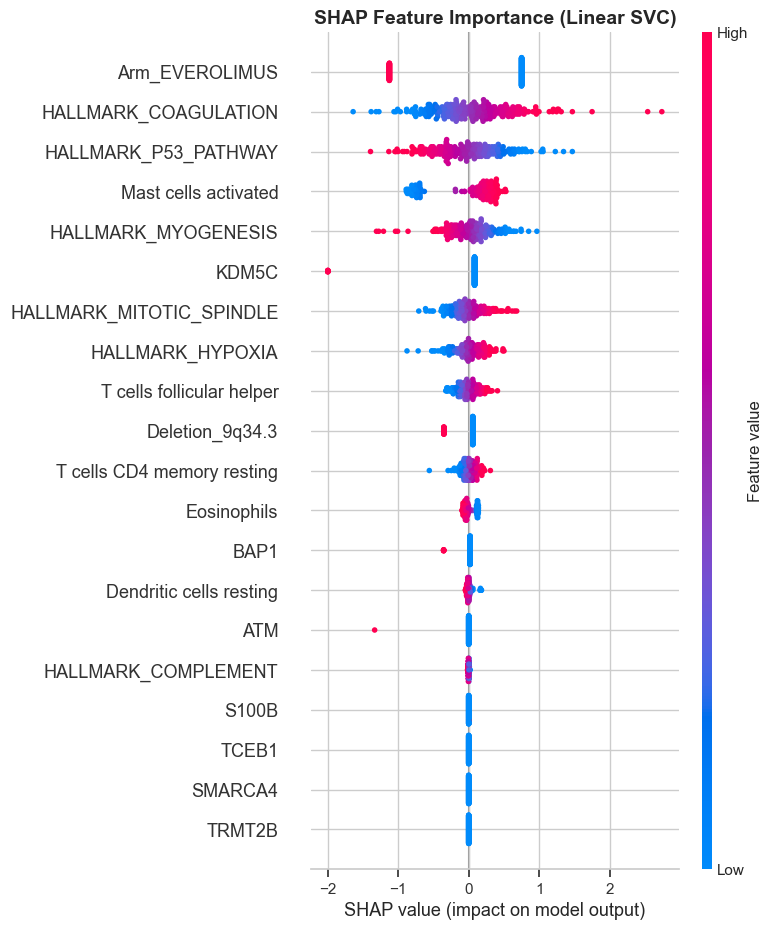


Top 10 Most Important Features:
   1. Arm_EVEROLIMUS                 0.8927
   2. HALLMARK_COAGULATION           0.4580
   3. HALLMARK_P53_PATHWAY           0.3888
   4. Mast cells activated           0.3859
   5. HALLMARK_MYOGENESIS            0.2424
   6. KDM5C                          0.1859
   7. HALLMARK_MITOTIC_SPINDLE       0.1787
   8. HALLMARK_HYPOXIA               0.1583
   9. T cells follicular helper      0.1214
  10. Deletion_9q34.3                0.1179


In [30]:
import shap

# Select best model by ROC-AUC
best_name = max(results, key=lambda k: results[k]['roc_auc_mean'])
best_pipeline = pipelines[best_name]
print(f'Best model: {best_name}')
print(f'  ROC-AUC: {results[best_name]["ROC-AUC"]}')
print(f'  F1: {results[best_name]["F1"]}')
print(f'  Bal. Acc.: {results[best_name]["Bal. Acc."]}')

# Fit best pipeline on full training data
print(f'\nFitting {best_name} on full training data...')
best_pipeline.fit(X_combined, y_train)
print('Done.')

# Extract selected feature names
selector = best_pipeline.named_steps['selector']
selected_mask = selector.get_support()
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_mask[i]]
print(f'\nSelected {len(selected_features)} features (k=20):')
print(selected_features)

# Get transformed data for SHAP
X_scaled = best_pipeline.named_steps['scaler'].transform(X_combined)
X_selected = best_pipeline.named_steps['selector'].transform(X_scaled)
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)

# SHAP explainer (choose based on model type)
clf = best_pipeline.named_steps['clf']
print(f'\nGenerating SHAP explanations...')
if hasattr(clf, 'feature_importances_'):  # XGBoost
    print('Using TreeExplainer (XGBoost)')
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_selected_df)
else:  # LogReg or SVC
    print('Using LinearExplainer (LogReg/SVC)')
    explainer = shap.LinearExplainer(clf, X_selected_df)
    shap_values = explainer.shap_values(X_selected_df)

# Handle binary-class SHAP output variants
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[1, :, :]

# SHAP beeswarm plot
print('Creating SHAP beeswarm plot...')
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_selected_df, show=False)
plt.title(f'SHAP Feature Importance ({best_name})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/shap_beeswarm.png', dpi=150, bbox_inches='tight')
print('Saved to: artifacts/shap_beeswarm.png')
plt.show()

# Top 10 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_10_idx = np.argsort(mean_abs_shap)[::-1][:10]
print('\n' + '='*60)
print('Top 10 Most Important Features:')
print('='*60)
for i, idx in enumerate(top_10_idx, 1):
    print(f'  {i:2d}. {selected_features[idx]:30s} {mean_abs_shap[idx]:.4f}')
print('='*60)


### 6.5 Model Performance Visualization

After cross-validation, we visualize the best model's performance through three complementary plots:

1. **ROC Curve**: Shows the trade-off between true positive rate and false positive rate across all classification thresholds. Area Under Curve (AUC) summarizes discrimination ability (1.0 = perfect, 0.5 = random).

2. **Confusion Matrix**: Displays actual vs predicted classifications. For imbalanced data, this reveals whether the model simply predicts the majority class or truly learns the minority (Responder) pattern.

3. **Model Comparison**: Side-by-side comparison of ROC-AUC, F1-score, and Balanced Accuracy for all 3 classifiers. Helps identify if the best model significantly outperforms alternatives or if performance is similar across methods.

**Important**: We use `cross_val_predict` to generate **out-of-fold predictions** from cross-validation. This provides an honest estimate of performance without data leakage (unlike fitting on train and predicting on train).

In [31]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Get CV probability predictions for ROC curve (honest out-of-fold predictions)
y_proba = cross_val_predict(best_pipeline, X_combined, y_train, cv=cv, method='predict_proba')[:, 1]
y_pred = cross_val_predict(best_pipeline, X_combined, y_train, cv=cv)

# ROC Curve data
fpr, tpr, _ = roc_curve(y_train, y_proba)
roc_auc_val = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'{best_name} (AUC = {roc_auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve ({best_name})')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Resp', 'Responder'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Confusion Matrix ({best_name})')

# Plot 3: Model Comparison Bar Chart
model_names = list(results.keys())
roc_vals = [float(results[n]['ROC-AUC'].split(' ')[0]) for n in model_names]
f1_vals = [float(results[n]['F1'].split(' ')[0]) for n in model_names]
ba_vals = [float(results[n]['Bal. Acc.'].split(' ')[0]) for n in model_names]

x = np.arange(len(model_names))
width = 0.25
axes[2].bar(x - width, roc_vals, width, label='ROC-AUC', color='steelblue')
axes[2].bar(x, f1_vals, width, label='F1', color='coral')
axes[2].bar(x + width, ba_vals, width, label='Bal. Acc.', color='mediumseagreen')
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=15, ha='right')
axes[2].set_ylabel('Score')
axes[2].set_title('Model Comparison (CV)')
axes[2].legend()
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nROC-AUC (from CV predictions): {roc_auc_val:.3f}')
print('Plot saved to: artifacts/model_comparison.png')


ValueError: cross_val_predict only works for partitions

### 6.6 Save Improved PipelineWe save the **best-performing model pipeline** and all associated metadata to a **separate artifact file** for deployment on unseen test data.**Critical considerations:**- **n_jobs=None**: sklearn and XGBoost estimators with `n_jobs=-1` contain thread pool references (`RLock`) that fail during serialization. We set all `n_jobs` attributes to `None` before saving.- **Separate file**: We save to `pipeline_artifacts_improved.joblib` to **preserve the original baseline artifacts** for comparison (students can see before/after models side-by-side).**Artifact contents:**- `pipeline`: Fitted sklearn Pipeline (scaler → selector → classifier)- `model_name`: Best classifier name (e.g., 'L1 LogReg')- `feature_columns`: All ~113 input feature names (clinical + pathway + deconvolution + genomic)- `selected_features`: 20 features selected by SelectKBest- `cv_results`: Cross-validation metrics for all 3 models- `class_ratio`: 106/31 ≈ 3.42 (for reference in XGBoost scale_pos_weight)- `random_state`: 42 (for reproducibility)The deployment notebook (`02_Model_Deployment.ipynb`) will load these artifacts to make predictions on test data.

In [32]:
import joblib# Set n_jobs=None on all components to avoid RLock serialization error (G12)for name, step in best_pipeline.named_steps.items():    if hasattr(step, 'n_jobs'):        step.n_jobs = None# Save improved artifacts (NEVER overwrite existing pipeline_artifacts.joblib)improved_artifacts = {    'pipeline': best_pipeline,    'model_name': best_name,    'feature_columns': list(X_combined.columns),  # all ~120 input features    'selected_features': selected_features,          # k=20 selected by SelectKBest    'cv_results': results,                           # full CV comparison    'class_ratio': float((y_train==0).sum()/(y_train==1).sum()),                           # for scale_pos_weight reference    'n_features_selected': len(selected_features),    'random_state': RANDOM_STATE,}joblib.dump(improved_artifacts, 'artifacts/pipeline_artifacts_improved.joblib')print('Improved artifacts saved to: artifacts/pipeline_artifacts_improved.joblib')print(f'Keys: {list(improved_artifacts.keys())}')print(f'Model: {best_name}, Features: {len(selected_features)}')# Verify original artifacts are untouchedoriginal = joblib.load('artifacts/pipeline_artifacts.joblib')print(f'\nOriginal artifacts still intact: {list(original.keys())}')

Improved artifacts saved to: artifacts/pipeline_artifacts_improved.joblib
Keys: ['pipeline', 'model_name', 'feature_columns', 'selected_features', 'cv_results', 'class_ratio', 'n_features_selected', 'random_state']
Model: Linear SVC, Features: 20



Original artifacts still intact: ['pipeline', 'model_name', 'pca', 'pca_columns', 'keep_genes', 'trans_scaler', 'pathway_scaler', 'cell_cols', 'clr_scaler', 'encoders', 'dummy_cols', 'binary_cols', 'ordinal_cols', 'num_cols', 'mice_kernel', 'feature_columns']
